In [2]:
# !curl -O https://download.pytorch.org/tutorial/data.zip; unzip data.zip

In [8]:
import os
import random
from string import ascii_letters

import torch
from torch import nn
import torch.nn.functional as F
from unidecode import unidecode

_ = torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
data_dir = "./data/names"

lang2label = {
    file_name.split(".")[0]: torch.tensor([i], dtype=torch.long)
    for i, file_name in enumerate(os.listdir(data_dir))
}

In [10]:
lang2label

{'Arabic': tensor([0]),
 'Chinese': tensor([1]),
 'Czech': tensor([2]),
 'Dutch': tensor([3]),
 'English': tensor([4]),
 'French': tensor([5]),
 'German': tensor([6]),
 'Greek': tensor([7]),
 'Irish': tensor([8]),
 'Italian': tensor([9]),
 'Japanese': tensor([10]),
 'Korean': tensor([11]),
 'Polish': tensor([12]),
 'Portuguese': tensor([13]),
 'Russian': tensor([14]),
 'Scottish': tensor([15]),
 'Spanish': tensor([16]),
 'Vietnamese': tensor([17])}

In [11]:
unidecode("Ślusàrski")

'Slusarski'

In [21]:
def name_to_tensor(name):
    """
    Convert a name to a tensor of character indices.
    """
    name = unidecode(name)
    return torch.tensor([ord(c) for c in name], dtype=torch.long).unsqueeze(0).to(device)

In [22]:
name_to_tensor("Ślusàrski")

tensor([[ 83, 108, 117, 115,  97, 114, 115, 107, 105]])

In [24]:
tensor_names = []
target_langs = []

for file in os.listdir(data_dir):
    with open(os.path.join(data_dir, file)) as f:
        lang = file.split(".")[0]
        names = [unidecode(line.rstrip()) for line in f]
        for name in names:
            try:
                tensor_names.append(name_to_tensor(name))
                target_langs.append(lang2label[lang])
            except KeyError:
                pass

In [25]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    range(len(target_langs)), 
    test_size=0.1, 
    shuffle=True, 
    stratify=target_langs
)

train_dataset = [
    (tensor_names[i], target_langs[i])
    for i in train_idx
]

test_dataset = [
    (tensor_names[i], target_langs[i])
    for i in test_idx
]

In [26]:
print(f"Train: {len(train_dataset)}")
print(f"Test: {len(test_dataset)}")

Train: 18066
Test: 2008


Creating Pure NumPy RNN from Scratch for Name Classification
Using provided datasets...
Training samples: 18066
Test samples: 2008
Vocabulary size: 123
Number of languages: 18
Training samples: 18066
Test samples: 2008

Model Configuration:
Hidden size: 64
Output size: 18
Learning rate: 0.01

Training RNN from scratch...
Epoch   0/50 | Loss: 1.4442 | Accuracy: 0.6310
Epoch  10/50 | Loss: 0.7123 | Accuracy: 0.9160
Epoch  20/50 | Loss: 0.7245 | Accuracy: 0.9194
Epoch  30/50 | Loss: 0.8111 | Accuracy: 0.8897
Epoch  40/50 | Loss: 1.1030 | Accuracy: 0.8044
Epoch  49/50 | Loss: 1.0843 | Accuracy: 0.8053


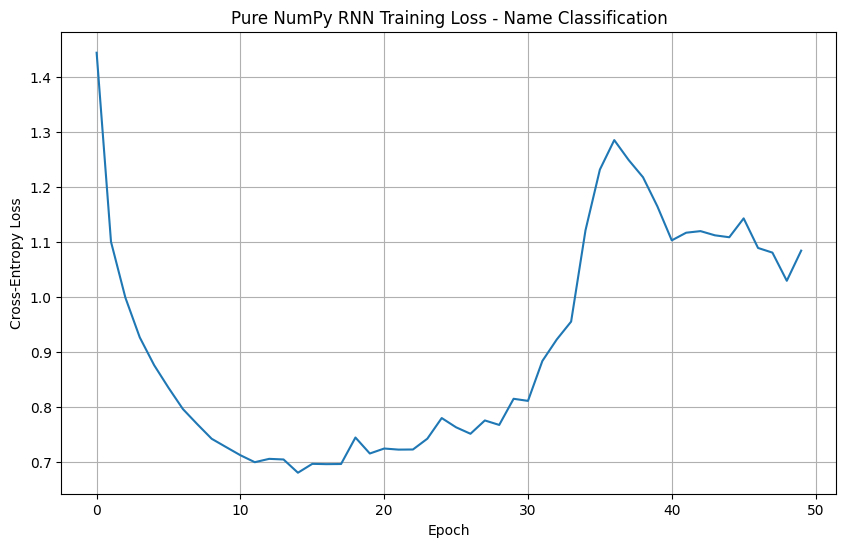


Evaluating model...
Test Accuracy: 0.6514 (1308/2008)

=== Sample Predictions ===
 1. ✓ 'Hahulin' -> Predicted: Russian (0.985) | True: Russian
    Top 3: Russian(0.985), English(0.007), French(0.002)
 2. ✓ 'Tzapin' -> Predicted: Russian (0.976) | True: Russian
    Top 3: Russian(0.976), English(0.006), French(0.003)
 3. ✓ 'Livadin' -> Predicted: Russian (0.968) | True: Russian
    Top 3: Russian(0.968), English(0.009), Dutch(0.008)
 4. ✗ 'Allen' -> Predicted: Russian (0.572) | True: English
    Top 3: Russian(0.572), Dutch(0.163), English(0.160)
 5. ✓ 'Shimanouchi' -> Predicted: Japanese (0.610) | True: Japanese
    Top 3: Japanese(0.610), Russian(0.176), Italian(0.132)
 6. ✓ 'Koury' -> Predicted: Arabic (0.581) | True: Arabic
    Top 3: Arabic(0.581), English(0.168), Russian(0.067)
 7. ✓ 'Lohvitsky' -> Predicted: Russian (0.998) | True: Russian
    Top 3: Russian(0.998), English(0.001), Czech(0.000)
 8. ✗ 'Khouri' -> Predicted: Japanese (0.431) | True: Arabic
    Top 3: Japanese(0.4

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

class RNNFromScratch:
    def __init__(self, vocab_size, hidden_size, output_size, learning_rate=0.01):
        """
        RNN implementation from scratch using pure NumPy
        Following the structure from your original implementation
        
        Args:
            vocab_size: Size of character vocabulary
            hidden_size: Size of hidden state
            output_size: Number of output classes (languages)
            learning_rate: Learning rate for gradient descent
        """
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        
        # Initialize parameters with small random values
        self.W_hx = np.random.randn(hidden_size, vocab_size) * 0.01    # Input to hidden
        self.W_hh = np.random.randn(hidden_size, hidden_size) * 0.01  # Hidden to hidden
        self.W_yh = np.random.randn(output_size, hidden_size) * 0.01  # Hidden to output
        
        # Biases
        self.b_h = np.zeros((hidden_size, 1))
        self.b_y = np.zeros((output_size, 1))
    
    def tanh(self, x):
        """Hyperbolic tangent activation"""
        return np.tanh(x)
    
    def dtanh(self, x):
        """Derivative of tanh"""
        return 1.0 - np.tanh(x) ** 2
    
    def softmax(self, x):
        """Softmax activation with numerical stability"""
        e_x = np.exp(x - np.max(x, axis=0, keepdims=True))
        return e_x / np.sum(e_x, axis=0, keepdims=True)
    
    def char_to_onehot(self, char_idx):
        """Convert character index to one-hot vector"""
        onehot = np.zeros((self.vocab_size, 1))
        if char_idx < self.vocab_size:
            onehot[char_idx, 0] = 1.0
        return onehot
    
    def forward_pass(self, name_chars, target_class=None):
        """
        Forward pass through RNN for a single name
        Similar to your rnn_forward function but adapted for variable length sequences
        """
        T = len(name_chars)  # Sequence length (name length)
        
        # Initialize states
        h = {-1: np.zeros((self.hidden_size, 1))}  # h_{-1} = 0
        a, z, y_hat = {}, {}, {}
        loss = 0
        
        # Forward pass through each character
        for t in range(T):
            # Convert character to one-hot vector
            x_t = self.char_to_onehot(name_chars[t])
            
            # Hidden state computation: a_t = W_hx * x_t + W_hh * h_{t-1} + b_h
            a[t] = np.dot(self.W_hx, x_t) + np.dot(self.W_hh, h[t-1]) + self.b_h
            
            # Apply tanh activation: h_t = tanh(a_t)
            h[t] = self.tanh(a[t])
        
        # Output computation (only at the final time step for classification)
        final_t = T - 1
        z[final_t] = np.dot(self.W_yh, h[final_t]) + self.b_y
        y_hat[final_t] = self.softmax(z[final_t])
        
        # Compute loss if target is provided
        if target_class is not None:
            # Create one-hot target
            target_onehot = np.zeros((self.output_size, 1))
            target_onehot[target_class, 0] = 1.0
            
            # Cross-entropy loss
            loss = -np.sum(target_onehot * np.log(y_hat[final_t] + 1e-8))
        
        # Cache for backpropagation
        cache = (name_chars, target_class, a, h, z, y_hat, T)
        return loss, cache
    
    def backward_pass(self, cache):
        """
        Backpropagation through time (following your rnn_backward structure)
        """
        name_chars, target_class, a, h, z, y_hat, T = cache
        
        # Initialize gradient accumulators
        dW_hx = np.zeros_like(self.W_hx)
        dW_hh = np.zeros_like(self.W_hh)
        db_h = np.zeros_like(self.b_h)
        dW_yh = np.zeros_like(self.W_yh)
        db_y = np.zeros_like(self.b_y)
        
        # Create target one-hot
        target_onehot = np.zeros((self.output_size, 1))
        target_onehot[target_class, 0] = 1.0
        
        # Gradient of output layer (only at final time step)
        final_t = T - 1
        dz = y_hat[final_t] - target_onehot
        
        # Output layer gradients
        dW_yh += np.dot(dz, h[final_t].T)
        db_y += dz
        
        # Initialize gradient flowing back through time
        dh_next = np.dot(self.W_yh.T, dz)
        
        # Backpropagate through time (from final_t to 0)
        for t in reversed(range(T)):
            # Gradient w.r.t hidden state
            if t == final_t:
                dh = dh_next  # From output layer
            else:
                dh = dh_next  # From future time step
            
            # Gradient w.r.t pre-activation
            da = self.dtanh(a[t]) * dh
            
            # Gradients w.r.t parameters
            dW_hh += np.dot(da, h[t-1].T)
            
            x_t = self.char_to_onehot(name_chars[t])
            dW_hx += np.dot(da, x_t.T)
            
            db_h += da
            
            # Gradient for next iteration (previous time step)
            dh_next = np.dot(self.W_hh.T, da)
        
        # Gradient clipping (same as your implementation)
        for dparam in [dW_hx, dW_hh, db_h, dW_yh, db_y]:
            np.clip(dparam, -5, 5, out=dparam)
        
        gradients = {
            'dW_hx': dW_hx,
            'dW_hh': dW_hh,
            'db_h': db_h,
            'dW_yh': dW_yh,
            'db_y': db_y
        }
        
        return gradients
    
    def update_parameters(self, gradients):
        """Update parameters using gradient descent (same as your implementation)"""
        self.W_hx -= self.learning_rate * gradients['dW_hx']
        self.W_hh -= self.learning_rate * gradients['dW_hh']
        self.b_h -= self.learning_rate * gradients['db_h']
        self.W_yh -= self.learning_rate * gradients['dW_yh']
        self.b_y -= self.learning_rate * gradients['db_y']
    
    def predict(self, name_chars):
        """Make prediction for a single name (similar to your predict function)"""
        T = len(name_chars)
        h = {-1: np.zeros((self.hidden_size, 1))}
        
        # Forward pass only
        for t in range(T):
            x_t = self.char_to_onehot(name_chars[t])
            h[t] = self.tanh(np.dot(self.W_hx, x_t) + np.dot(self.W_hh, h[t-1]) + self.b_h)
        
        # Output at final time step
        z_final = np.dot(self.W_yh, h[T-1]) + self.b_y
        y_hat_final = self.softmax(z_final)
        
        # Return class with highest probability
        predicted_class = np.argmax(y_hat_final)
        confidence = np.max(y_hat_final)
        
        return predicted_class, confidence, y_hat_final.flatten()

def prepare_data_from_pytorch_format(train_dataset, test_dataset):
    """
    Convert PyTorch tensor format to pure NumPy format
    """
    # Convert training data
    train_data_np = []
    for name_tensor, target_tensor in train_dataset:
        # Convert tensor to list of character indices
        name_chars = name_tensor.squeeze().cpu().numpy().tolist() if hasattr(name_tensor, 'cpu') else name_tensor.squeeze().tolist()
        target_class = target_tensor.item() if hasattr(target_tensor, 'item') else target_tensor
        train_data_np.append((name_chars, target_class))
    
    # Convert test data
    test_data_np = []
    for name_tensor, target_tensor in test_dataset:
        name_chars = name_tensor.squeeze().cpu().numpy().tolist() if hasattr(name_tensor, 'cpu') else name_tensor.squeeze().tolist()
        target_class = target_tensor.item() if hasattr(target_tensor, 'item') else target_tensor
        test_data_np.append((name_chars, target_class))
    
    # Find vocabulary size
    all_chars = []
    for name_chars, _ in train_data_np + test_data_np:
        all_chars.extend(name_chars)
    vocab_size = max(all_chars) + 1
    
    return train_data_np, test_data_np, vocab_size

def create_dummy_data():
    """Create dummy name data for testing"""
    # Language to label mapping
    lang2label = {
        'English': 0, 'French': 1, 'German': 2, 'Spanish': 3, 'Italian': 4
    }
    
    # Sample names for each language
    dummy_names = {
        'English': ['Smith', 'Johnson', 'Williams', 'Brown', 'Jones', 'Garcia', 'Miller', 'Davis', 'Rodriguez', 'Martinez'],
        'French': ['Martin', 'Bernard', 'Dubois', 'Thomas', 'Robert', 'Petit', 'Durand', 'Leroy', 'Moreau', 'Simon'],
        'German': ['Mueller', 'Schmidt', 'Schneider', 'Fischer', 'Weber', 'Meyer', 'Wagner', 'Becker', 'Schulz', 'Hoffmann'],
        'Spanish': ['Garcia', 'Rodriguez', 'Martinez', 'Lopez', 'Gonzalez', 'Hernandez', 'Perez', 'Sanchez', 'Ramirez', 'Cruz'],
        'Italian': ['Rossi', 'Russo', 'Ferrari', 'Esposito', 'Bianchi', 'Romano', 'Colombo', 'Ricci', 'Marino', 'Greco']
    }
    
    train_data = []
    test_data = []
    
    for lang, names in dummy_names.items():
        for i, name in enumerate(names):
            # Convert name to character indices
            name_chars = [ord(c) for c in name.lower()]  # Convert to lowercase and get ASCII values
            target_class = lang2label[lang]
            
            # Split into train/test
            if i < 7:  # First 7 names for training
                train_data.append((name_chars, target_class))
            else:  # Last 3 names for testing
                test_data.append((name_chars, target_class))
    
    # Find vocabulary size
    all_chars = []
    for name_chars, _ in train_data + test_data:
        all_chars.extend(name_chars)
    vocab_size = max(all_chars) + 1
    
    # Create label to language mapping
    label2lang = {v: k for k, v in lang2label.items()}
    
    return train_data, test_data, vocab_size, label2lang

def train_rnn(model, train_data, num_epochs=100, print_every=10):
    """Train the RNN model (following your training structure)"""
    losses = []
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        correct_predictions = 0
        total_predictions = 0
        
        # Shuffle training data
        random.shuffle(train_data)
        
        for name_chars, target_class in train_data:
            # Forward pass
            loss, cache = model.forward_pass(name_chars, target_class)
            epoch_loss += loss
            
            # Backward pass
            gradients = model.backward_pass(cache)
            
            # Update parameters
            model.update_parameters(gradients)
            
            # Calculate accuracy
            predicted_class, _, _ = model.predict(name_chars)
            if predicted_class == target_class:
                correct_predictions += 1
            total_predictions += 1
        
        # Track average loss per epoch
        avg_loss = epoch_loss / len(train_data)
        accuracy = correct_predictions / total_predictions
        losses.append(avg_loss)
        
        if epoch % print_every == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch:3d}/{num_epochs} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")
    
    return losses

def evaluate_model(model, test_data, label2lang):
    """Evaluate model performance (following your evaluation structure)"""
    correct = 0
    total = 0
    predictions_by_lang = defaultdict(list)
    
    print("\nEvaluating model...")
    
    for name_chars, target_class in test_data:
        predicted_class, confidence, probabilities = model.predict(name_chars)
        
        if predicted_class == target_class:
            correct += 1
        total += 1
        
        # Store predictions for analysis
        true_lang = label2lang[target_class]
        pred_lang = label2lang[predicted_class]
        predictions_by_lang[true_lang].append((pred_lang, confidence, predicted_class == target_class))
    
    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f} ({correct}/{total})")
    
    return accuracy, predictions_by_lang

def demonstrate_predictions(model, test_data, label2lang, num_examples=10):
    """Show sample predictions"""
    print(f"\n=== Sample Predictions ===")
    
    # Get random samples
    samples = random.sample(test_data, min(num_examples, len(test_data)))
    
    for i, (name_chars, target_class) in enumerate(samples):
        # Convert character indices back to name
        name = ''.join([chr(c) for c in name_chars if c < 256])
        
        predicted_class, confidence, probabilities = model.predict(name_chars)
        
        true_lang = label2lang[target_class]
        pred_lang = label2lang[predicted_class]
        
        # Get top 3 predictions
        top_indices = np.argsort(probabilities)[-3:][::-1]
        top_langs = [(label2lang[idx], probabilities[idx]) for idx in top_indices]
        
        status = "✓" if predicted_class == target_class else "✗"
        print(f"{i+1:2d}. {status} '{name}' -> Predicted: {pred_lang} ({confidence:.3f}) | True: {true_lang}")
        print(f"    Top 3: {', '.join([f'{lang}({prob:.3f})' for lang, prob in top_langs])}")

# Main execution
if __name__ == "__main__":
    print("Creating Pure NumPy RNN from Scratch for Name Classification")
    print("=" * 60)
    
    # Try to use provided datasets, otherwise create dummy data
    try:
        # Check if train_dataset and test_dataset exist from your PyTorch code
        print(f"Using provided datasets...")
        print(f"Training samples: {len(train_dataset)}")
        print(f"Test samples: {len(test_dataset)}")
        
        # Convert PyTorch format to NumPy format
        train_data, test_data, vocab_size = prepare_data_from_pytorch_format(train_dataset, test_dataset)
        
        # Create label to language mapping
        label2lang = {v.item(): k for k, v in lang2label.items()}
        
    except NameError:
        print("Creating dummy datasets for demonstration...")
        train_data, test_data, vocab_size, label2lang = create_dummy_data()
    
    print(f"Vocabulary size: {vocab_size}")
    print(f"Number of languages: {len(label2lang)}")
    print(f"Training samples: {len(train_data)}")
    print(f"Test samples: {len(test_data)}")
    
    # Model parameters
    hidden_size = 64
    output_size = len(label2lang)
    learning_rate = 0.01
    
    print(f"\nModel Configuration:")
    print(f"Hidden size: {hidden_size}")
    print(f"Output size: {output_size}")
    print(f"Learning rate: {learning_rate}")
    
    # Create and train model
    model = RNNFromScratch(vocab_size, hidden_size, output_size, learning_rate)
    
    print(f"\nTraining RNN from scratch...")
    losses = train_rnn(model, train_data, num_epochs=50, print_every=10)
    
    # Plot training loss
    plt.figure(figsize=(10, 6))
    plt.plot(losses)
    plt.title('Pure NumPy RNN Training Loss - Name Classification')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-Entropy Loss')
    plt.grid(True)
    plt.show()
    
    # Evaluate model
    accuracy, predictions_by_lang = evaluate_model(model, test_data, label2lang)
    
    # Show sample predictions
    demonstrate_predictions(model, test_data, label2lang, num_examples=8)
    
    print(f"\n=== Model Summary ===")
    print(f"Final Test Accuracy: {accuracy:.4f}")
    total_params = (model.W_hx.size + model.W_hh.size + model.W_yh.size + 
                   model.b_h.size + model.b_y.size)
    print(f"Total Parameters: {total_params}")
    print("Training completed successfully using pure NumPy!")